## Libraries

In [1]:
import pandas as pd
import geopandas as gpd
import os
import json
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import math
import numpy as np

## Linking Functions notebook

In [2]:
# Adding path to system
import sys
sys.path.append(r"C:\\Users\\eliya\\Documents\\עבודה\\עוזר מחקר\\4. פרויקטים\\1. quality measures\\1. Feature Completeness")

In [3]:
# Importing relevant functions
import importlib
import functions
importlib.reload(functions)
from functions import get_len, get_count, get_area, semi_norm_mix_transform

[NbConvertApp] Converting notebook C:/Users/eliya/Documents/עבודה/עוזר מחקר/4. פרויקטים/1. quality measures/1. Feature Completeness/functions.ipynb to script
[NbConvertApp] Writing 10735 bytes to C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\functions.py
[NbConvertApp] Converting notebook C:/Users/eliya/Documents/עבודה/עוזר מחקר/4. פרויקטים/1. quality measures/1. Feature Completeness/functions.ipynb to script
[NbConvertApp] Writing 10735 bytes to C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\functions.py


##### Original function used in this notebook

In [ ]:
# Generate a mixed transformation ratio of cumulative size divided by cumulative counts
def semi_norm_mix_transform(count_gdf, size_gdf, value_column='value', alpha=0.3, time_thresh=2):
    '''
    Receives two GeoDataFrames (assumes identical timestamps and geometry):
    1) A cumulative count of added features by timestamps
    2) A cumulative length of all features by timestamps

    The function converts timestamp to actual datetime format, transforms the values to a mixed normalized percentage of added lengths per each added unit.
    After that, the function applies the following statistical test:
        If all cumulative change percentage is below 3% for given previous years (default value - 2), the data is considered saturated, and then the umulatitve percentage of data is calculated up to that point.

    The output is a DataFrame with cumulative percentages and all calculated values for saturated data and the first timestamp where the data is 80% saturated.
    '''
    # Fix timestamp
    count_gdf['timestamp'] = pd.to_datetime(count_gdf['timestamp'])
    size_gdf['timestamp'] = pd.to_datetime(size_gdf['timestamp'])

    # Sort both DataFrames by timestamp and reset index for proper alignment
    count_gdf = count_gdf.sort_values('timestamp').reset_index(drop=True)
    size_gdf = size_gdf.sort_values('timestamp').reset_index(drop=True)

    # Transform values
    count_gdf['cumulative_percentage'] = size_gdf[value_column] / count_gdf[value_column]
    count_gdf['cumulative_percentage'] = count_gdf['cumulative_percentage'].fillna(0) # Dealing with periods without addition
    count_gdf['normalized_cum_per'] = count_gdf['cumulative_percentage'] / count_gdf['cumulative_percentage'].max()

    # Extract inputs from ime threshold onwards
    cutoff = count_gdf['timestamp'].max() - pd.DateOffset(years=time_thresh)
    thresh = count_gdf[count_gdf['timestamp'] >= cutoff].copy()

    # Apply completeness test for level alpha
    thresh['test'] = (thresh['normalized_cum_per'] < alpha).astype(int)

    ## If any row fails test, data is considered incomplete
    if any(thresh['test'] == 0):
        print('Data incomplete')
        return count_gdf
    
    ## For data considered full in polygon
    else:
        # Reshape output values
        count_gdf['cumulative_size'] = size_gdf[value_column] # Append size column
        count_gdf = count_gdf[['timestamp', value_column, 'cumulative_size', 'cumulative_percentage', 'normalized_cum_per']]
        
        # Extract max values
        saturated = thresh.iloc[0].drop('test') # Defined saturated value
        real_max = count_gdf.iloc[-1] # Emprical maximal value
        
        # Filter data until saturation
        count_gdf = count_gdf[count_gdf['timestamp'] < saturated['timestamp']].copy()

        # Concatenating maximal values (saturation, empirical)
        output = pd.concat([count_gdf, 
                   pd.DataFrame([saturated]), 
                   pd.DataFrame([real_max])], 
                  ignore_index=True)
        
        # Calculating saturation levels
        output['percentage_until_saturation'] = output[value_column] / saturated[value_column]
        output = output.rename(columns={value_column : 'cumulative_count'}) # Rename count column (after operation for corect ambiguity)


        # Extracting 80% saturation timestamp
        saturated_time = output[output['percentage_until_saturation'] >= 0.8]['timestamp'].iloc[0]
        print(f'Polygon 80% saturated at {saturated_time}')

        return output

## Tests on previous places

In [4]:
heid_bbox = "8.1543,49.1757,9.1351,49.6884" # Heidelberg

par_bbox = "2.255031,48.813564,2.426418,48.904637" # Paris

hai_bbox = "108.4078,18.0357,111.1148,20.1493" # China

thai_bbox = "99.6253,9.3452,100.201,10.1602" # Thailand

bshemesh_bbox = "34.938188,31.689471,35.035005,31.786876" # Israel

### Tests

In [10]:
# Extracting data using API

## Heidelberg
print('Heidelberg:')
heid_c = get_count(heid_bbox, time="2008-01-01/2025-01-01/P1M")
heid_c2 = get_count(heid_bbox, filter='type:way and building=*', time="2008-01-01/2025-01-01/P1M")
heid_l = get_len(heid_bbox, time="2008-01-01/2025-01-01/P1M")
heid_a = get_area(heid_bbox, time="2008-01-01/2025-01-01/P1M")

## Paris
print('\nParis:')
par_c = get_count(par_bbox, time="2008-01-01/2025-01-01/P1M")
par_c2 = get_count(par_bbox, filter='type:way and building=*', time="2008-01-01/2025-01-01/P1M")
par_l = get_len(par_bbox, time="2008-01-01/2025-01-01/P1M")
par_a = get_area(par_bbox, time="2008-01-01/2025-01-01/P1M")

## Hainan
print('\nHainan:')
hain_c = get_count(hai_bbox, time="2008-01-01/2025-01-01/P1M")
hain_c2 = get_count(hai_bbox, filter='type:way and building=*', time="2008-01-01/2025-01-01/P1M")
hain_l = get_len(hai_bbox, time="2008-01-01/2025-01-01/P1M")
hain_a = get_area(hai_bbox, time="2008-01-01/2025-01-01/P1M")

## Thailand islands
print('\nThailand Islands:')
thai_c = get_count(thai_bbox, time="2008-01-01/2025-01-01/P1M")
thai_c2 = get_count(thai_bbox, filter='type:way and building=*', time="2008-01-01/2025-01-01/P1M")
thai_l = get_len(thai_bbox, time="2008-01-01/2025-01-01/P1M")
thai_a = get_area(thai_bbox, time="2008-01-01/2025-01-01/P1M")

## Beit Shemesh
print('\nBet Shemesh:')
isr_c = get_count(bshemesh_bbox, time="2008-01-01/2025-01-01/P1M")
isr_c2 = get_count(bshemesh_bbox, filter='type:way and building=*', time="2008-01-01/2025-01-01/P1M")
isr_l = get_len(bshemesh_bbox, time="2008-01-01/2025-01-01/P1M")
isr_a = get_area(bshemesh_bbox, time="2008-01-01/2025-01-01/P1M")

Succesfully extracted counts
Succesfully extracted counts
Succesfully extracted lengths
Succesfully extracted areas
Succesfully extracted counts
Succesfully extracted counts
Succesfully extracted lengths
Succesfully extracted areas
Succesfully extracted counts
Succesfully extracted counts
Succesfully extracted lengths
Succesfully extracted areas
Succesfully extracted counts
Succesfully extracted counts
Succesfully extracted lengths
Succesfully extracted areas
Succesfully extracted counts
Succesfully extracted counts
Succesfully extracted lengths
Succesfully extracted areas


In [11]:
# Initiating threshold test
heid_roads_test = semi_norm_mix_transform(heid_c, heid_l, alpha=0.2)
par_roads_test = semi_norm_mix_transform(par_c, par_l, alpha=0.2)
hain_roads_test = semi_norm_mix_transform(hain_c, hain_l, alpha=0.2)
thai_roads_test = semi_norm_mix_transform(thai_c, thai_l, alpha=0.2)
isr_roads_test = semi_norm_mix_transform(isr_c, isr_l, alpha=0.2)

Data incomplete
Data incomplete
Polygon 80% saturated at 2022-02-01 00:00:00+00:00
Polygon 80% saturated at 2021-06-01 00:00:00+00:00
Polygon 80% saturated at 2021-10-01 00:00:00+00:00


In [12]:
# Initiating threshold test for buildings
heid_bldgs_test = semi_norm_mix_transform(heid_c2, heid_a, alpha=0.2)
par_bldgs_test = semi_norm_mix_transform(par_c2, par_a, alpha=0.2)
hain_bldgs_test = semi_norm_mix_transform(hain_c2, hain_a, alpha=0.2)
thai_bldgs_test = semi_norm_mix_transform(thai_c2, thai_a, alpha=0.2)
isr_bldgs_test = semi_norm_mix_transform(isr_c2, isr_a, alpha=0.2)

Polygon 80% saturated at 2018-12-01 00:00:00+00:00
Polygon 80% saturated at 2010-11-01 00:00:00+00:00
Polygon 80% saturated at 2020-01-01 00:00:00+00:00
Polygon 80% saturated at 2019-03-01 00:00:00+00:00
Polygon 80% saturated at 2020-12-01 00:00:00+00:00


### Plots

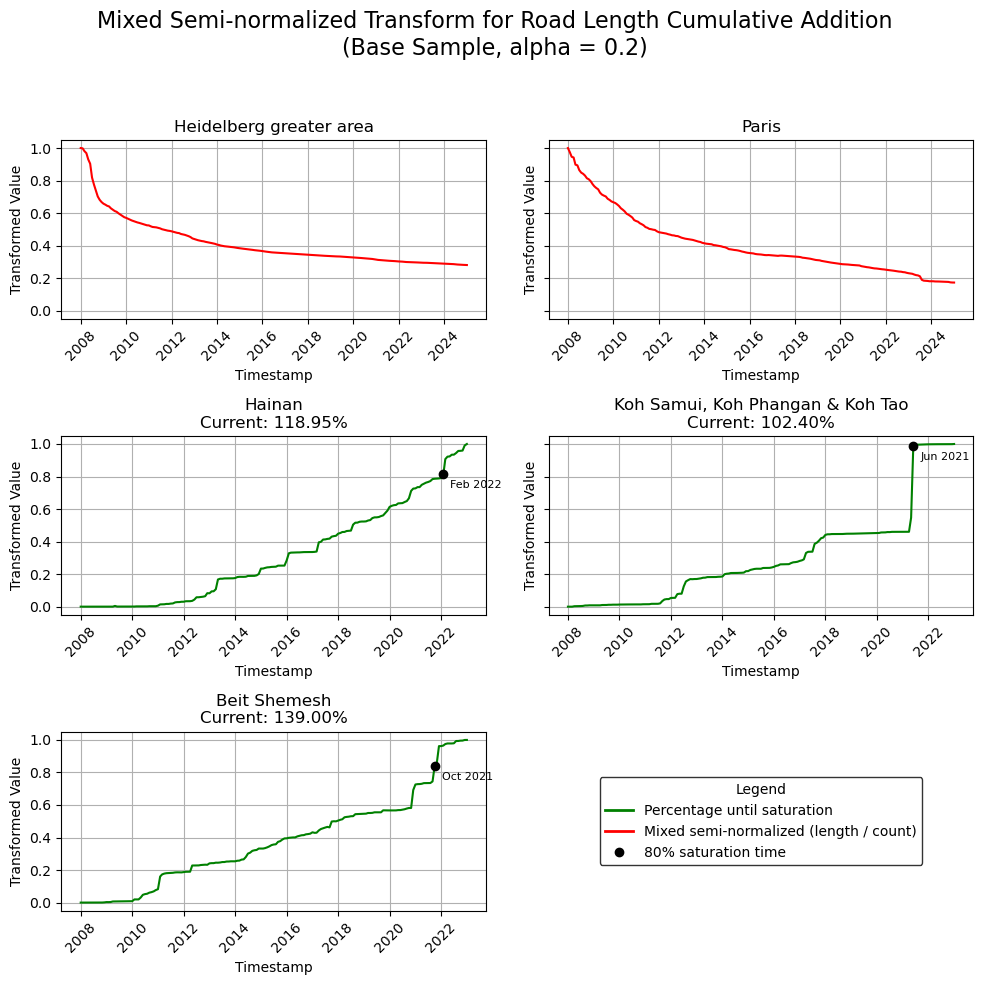

In [13]:
# Defining dataframes and subplot titles
dfs = [heid_roads_test, par_roads_test, hain_roads_test, thai_roads_test, isr_roads_test]
titles = ['Heidelberg greater area', 'Paris', 'Hainan', 'Koh Samui, Koh Phangan & Koh Tao', 'Beit Shemesh']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10), sharey=True)
axes = axes.flatten()

for i, (df, ax) in enumerate(zip(dfs, axes)):
    # Saturated values:
    if 'percentage_until_saturation' in df.columns:
        # Plotting
        df_plt = df.iloc[:-1]
        ax.plot(df_plt['timestamp'], df_plt['percentage_until_saturation'], linestyle='-', color='g', label='Percentage until saturation')
        
        # Adding current "percentage" to title
        last_val = df['percentage_until_saturation'].iloc[-1]
        ax.set_title(f"{titles[i]}\nCurrent: {last_val:.2%}")

        # Adding saturation point
        saturation = df[df['percentage_until_saturation'] >= 0.8].iloc[0]
        ax.scatter(saturation['timestamp'], saturation['percentage_until_saturation'], color='black', zorder=5, label='80% saturation')
        ax.annotate(pd.to_datetime(saturation['timestamp']).strftime('%b %Y'), xy=(saturation['timestamp'], saturation['percentage_until_saturation']),
                    xytext=(5, -10), textcoords='offset points', fontsize=8, color='black')

    # Un-saturated values:      
    else: 
        ax.plot(df['timestamp'], df['normalized_cum_per'], linestyle='-', color='r', label='Mixed semi-normalized (length / count)')
        ax.set_title(titles[i])
    ax.set_ylabel('Transformed Value')
    ax.set_xlabel('Timestamp')
    ax.tick_params(axis='x', rotation=45)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(True)

# Setting legend
empty_ax = axes[-1]
empty_ax.axis('off')
legend_elements = [
    Line2D([0], [0], color='g', lw=2, label='Percentage until saturation'),
    Line2D([0], [0], color='r', lw=2, label='Mixed semi-normalized (length / count)'),
    Line2D([0], [0], marker='o', color='black', linestyle='', label='80% saturation time')
]
legend = empty_ax.legend(handles=legend_elements, loc='center', frameon=True, title='Legend')
legend.get_frame().set_edgecolor('black')

# Showing plots
fig.suptitle('Mixed Semi-normalized Transform for Road Length Cumulative Addition\n(Base Sample, alpha = 0.2)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

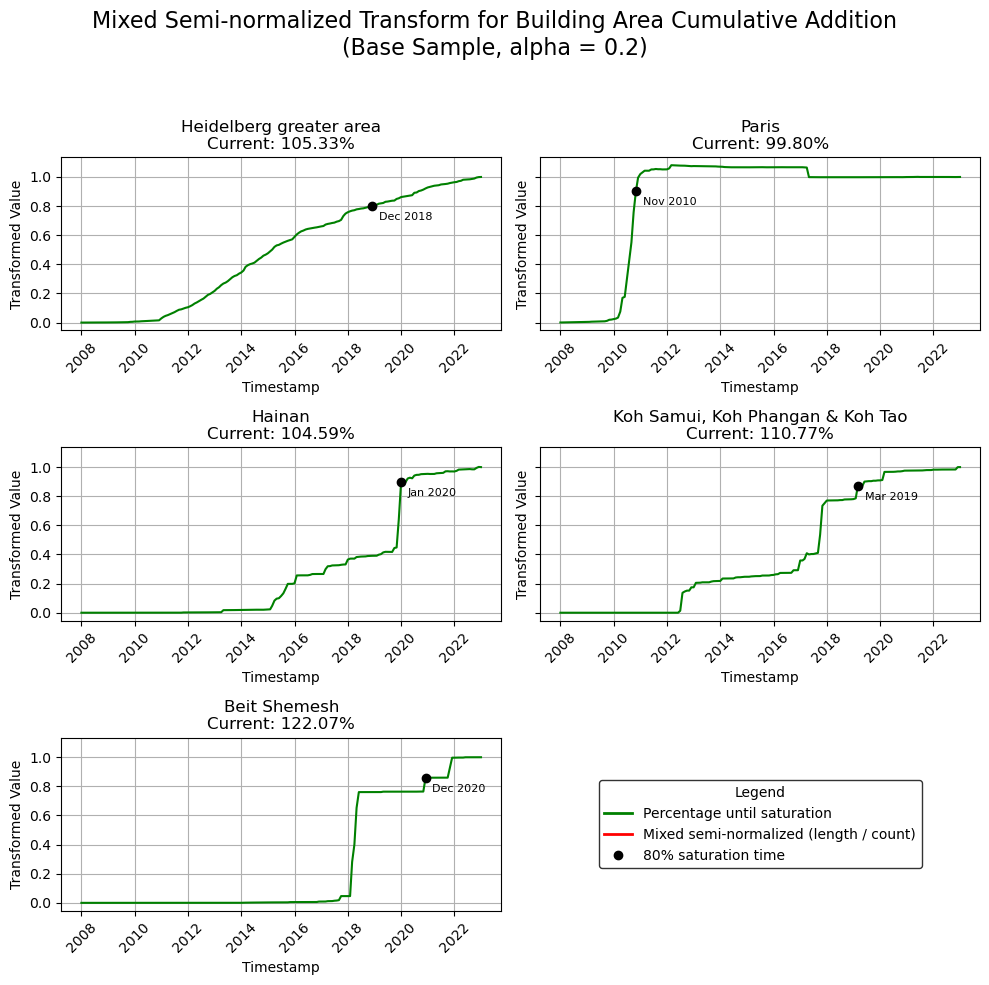

In [9]:
# Defining dataframes and subplot titles
dfs = [heid_bldgs_test, par_bldgs_test, hain_bldgs_test, thai_bldgs_test, isr_bldgs_test]
titles = ['Heidelberg greater area', 'Paris', 'Hainan', 'Koh Samui, Koh Phangan & Koh Tao', 'Beit Shemesh']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10), sharey=True)
axes = axes.flatten()

for i, (df, ax) in enumerate(zip(dfs, axes)):
    # Saturated values:
    if 'percentage_until_saturation' in df.columns:
        # Plotting
        df_plt = df.iloc[:-1]
        ax.plot(df_plt['timestamp'], df_plt['percentage_until_saturation'], linestyle='-', color='g', label='Percentage until saturation')
        
        # Adding current "percentage" to title
        last_val = df['percentage_until_saturation'].iloc[-1]
        ax.set_title(f"{titles[i]}\nCurrent: {last_val:.2%}")

        # Adding saturation point
        saturation = df[df['percentage_until_saturation'] >= 0.8].iloc[0]
        ax.scatter(saturation['timestamp'], saturation['percentage_until_saturation'], color='black', zorder=5, label='80% saturation')
        ax.annotate(pd.to_datetime(saturation['timestamp']).strftime('%b %Y'), xy=(saturation['timestamp'], saturation['percentage_until_saturation']),
                    xytext=(5, -10), textcoords='offset points', fontsize=8, color='black')

    # Un-saturated values:      
    else: 
        ax.plot(df['timestamp'], df['normalized_cum_per'], linestyle='-', color='r', label='Mixed semi-normalized (length / count)')
        ax.set_title(titles[i])
    ax.set_ylabel('Transformed Value')
    ax.set_xlabel('Timestamp')
    ax.tick_params(axis='x', rotation=45)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(True)

# Setting legend
empty_ax = axes[-1]
empty_ax.axis('off')
legend_elements = [
    Line2D([0], [0], color='g', lw=2, label='Percentage until saturation'),
    Line2D([0], [0], color='r', lw=2, label='Mixed semi-normalized (length / count)'),
    Line2D([0], [0], marker='o', color='black', linestyle='', label='80% saturation time')
]
legend = empty_ax.legend(handles=legend_elements, loc='center', frameon=True, title='Legend')
legend.get_frame().set_edgecolor('black')

# Showing plots
fig.suptitle('Mixed Semi-normalized Transform for Building Area Cumulative Addition\n(Base Sample, alpha = 0.2)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Events check

### Sample

In [15]:
b_boxes = gpd.read_file("C:/Users/eliya/Documents/עבודה/עוזר מחקר/Data/Large-scale events/event_weights_grid.shp")

In [16]:
# Applying event names
b_boxes = b_boxes.rename(columns={
    'events_w_1' : 'local_knowledge',
    'events_w_2' : 'tag_import',
    'events_w_3' : 'remote_event',
    'events_w_4' : 'late_import',
    'events_w_5' : 'geometry_import',
    'events_w_6' : 'weight_sum',
    'events_wei' : 'early_import'
})

In [17]:
# Extracting bounding box coordinates
b_boxes[['minx', 'miny', 'maxx', 'maxy']] = b_boxes.bounds
b_boxes['bbox'] = b_boxes.apply(
    lambda row: f"{row['minx']},{row['miny']},{row['maxx']},{row['maxy']}",
    axis=1
)

In [18]:
# Splitting into different event types
local_knowledge_event = b_boxes[b_boxes['local_knowledge'] != 0][['id', 'entities', 'local_knowledge', 'geometry', 'minx', 'miny', 'maxx', 'maxy', 'bbox']]
remote_event = b_boxes[b_boxes['remote_event'] != 0][['id', 'entities', 'remote_event', 'geometry', 'minx', 'miny', 'maxx', 'maxy', 'bbox']]
early_import = b_boxes[b_boxes['early_import'] != 0][['id', 'entities', 'early_import', 'geometry', 'minx', 'miny', 'maxx', 'maxy', 'bbox']]
geometry_import = b_boxes[b_boxes['geometry_import'] != 0][['id', 'entities', 'geometry_import', 'geometry', 'minx', 'miny', 'maxx', 'maxy', 'bbox']]
tag_import = b_boxes[b_boxes['tag_import'] != 0][['id', 'entities', 'tag_import', 'geometry', 'minx', 'miny', 'maxx', 'maxy', 'bbox']]
late_import = b_boxes[b_boxes['late_import'] != 0][['id', 'entities', 'late_import', 'geometry', 'minx', 'miny', 'maxx', 'maxy', 'bbox']]

In [19]:
# Sampling areas with significant percentage of event type for analysis
local_knowledge_samp = local_knowledge_event[local_knowledge_event['local_knowledge'] > 60]
remote_event_samp = remote_event[remote_event['remote_event'] > 80]
early_import_samp = early_import[early_import['early_import'] > 80]
geometry_import_samp = geometry_import[geometry_import['geometry_import'] > 50]
tag_import_samp = tag_import[tag_import['tag_import'] > 45]
late_import_samp = late_import[late_import['late_import'] > 60]


# Printing sample sizes
print('Number of sampled areas (n):')
print(f'   Local knowledge: {local_knowledge_samp.shape[0]}')
print(f'   Remote event: {remote_event_samp.shape[0]}')
print(f'   Early imports: {early_import_samp.shape[0]}')
print(f'   Geometry imports: {geometry_import_samp.shape[0]}')
print(f'   Tag imports: {tag_import_samp.shape[0]}')
print(f'   Late imports: {late_import_samp.shape[0]}')
print(f'\nTotal sample size: n = {local_knowledge_samp.shape[0] +
                                      remote_event_samp.shape[0] +
                                      early_import_samp.shape[0] +
                                      geometry_import_samp.shape[0] +
                                      tag_import_samp.shape[0] +
                                      late_import_samp.shape[0]}')

Number of sampled areas (n):
   Local knowledge: 28
   Remote event: 259
   Early imports: 127
   Geometry imports: 8
   Tag imports: 9
   Late imports: 15

Total sample size: n = 446


In [20]:
# Preparing sample for concatenation
sampled = {
    'local_knowledge' : local_knowledge_samp,
    'remote_event' : remote_event_samp,
    'early_import' : early_import_samp,
    'geometry_import' : geometry_import_samp,
    'tag_import' : tag_import_samp,
    'late_import' : late_import_samp
}

for name, df in sampled.items():
    df = df.rename(columns={name: 'event_percentage'})
    df['event_type'] = name
    sampled[name] = df[['event_type', 'event_percentage', 'bbox', 'minx', 'miny', 'maxx', 'maxy']]

In [21]:
# Merging all samples to one big sample file
events_sample = pd.concat(sampled.values(), ignore_index=True)

In [22]:
# Verifying concatenation
print(f'Sample shape: {events_sample.shape}')
events_sample.head()

Sample shape: (446, 7)


,event_type,event_percentage,bbox,minx,miny,maxx,maxy
0,local_knowledge,63.997417,"-72.7734375,18.984375,-72.421875,19.16015625",-72.773438,18.984375,-72.421875,19.160156
1,local_knowledge,67.598822,"-72.421875,19.6875,-71.71875,20.0390625",-72.421875,19.687500,-71.718750,20.039062
2,local_knowledge,68.649403,"32.34375,-25.83984375,32.6953125,-25.6640625",32.343750,-25.839844,32.695312,-25.664062
3,local_knowledge,66.094857,"27.421875,-16.5234375,28.125,-16.171875",27.421875,-16.523438,28.125000,-16.171875
4,local_knowledge,66.532091,"34.453125,-19.6875,35.15625,-19.3359375",34.453125,-19.687500,35.156250,-19.335938


### Extract data using API

In [23]:
def wrap_api_query(row, query, filter='type:way and highway=*', time='2008-01-01/2025-01-01/P1M'):
    # Implement API extract function
    if query == 'count':
        df = get_count(row['bbox'], filter=filter, time=time)
    elif query == 'length':
        df = get_len(row['bbox'], filter=filter,time=time)
    elif query == 'area':
        df = get_area(row['bbox'], filter=filter,time=time)
    else:
        raise ValueError(f"Unknown query type: {query}")
    
    # Append identifier columns
    df['idx'] = row.name # one-to-one index
    df['event_type'] = row['event_type'] # event type
    df['event_percentage'] = row['event_percentage'] # percentage of event in bbox

    return df

#### Test on subsample

In [24]:
subset = events_sample.head(n=5)

In [28]:
# Use wrapper function to extract road counts for all subset rows
counts_rds = pd.concat(
    subset.apply(lambda row: wrap_api_query(row, query='count'), axis=1).tolist(),
    ignore_index=True
)

# Use wrapper function to extract road lengths for all subset rows
lengths = pd.concat(
    subset.apply(lambda row: wrap_api_query(row, query='length'), axis=1).tolist(),
    ignore_index=True
)

# Use wrapper function to extract road counts for all subset rows
counts_bld = pd.concat(
    subset.apply(lambda row: wrap_api_query(row, query='count', filter='type:way and building=*'), axis=1).tolist(),
    ignore_index=True
)

# Use wrapper function to extract building areas for all subset rows
areas = pd.concat(
    subset.apply(lambda row: wrap_api_query(row, query='area', filter='type:way and building=*'), axis=1).tolist(),
    ignore_index=True
)

In [29]:
roads_test = []
bldgs_test = []

for idx, count_group in counts_rds.groupby('idx'):
    len_group = lengths[lengths['idx'] == idx].copy() # grouping length dataframe entries
    t1 = semi_norm_mix_transform(count_group, len_group)
    t1.loc[:, 'idx'] = idx  # preserve original index
    roads_test.append(t1)

for idx, count_group in counts_bld.groupby('idx'):
    area_group = areas[areas['idx'] == idx].copy() # grouping area dataframe entries
    t2 = semi_norm_mix_transform(count_group, area_group)
    t2.loc[:, 'idx'] = idx # preserve original index
    bldgs_test.append(t2)

roads_test = pd.concat(roads_test, ignore_index=True)
bldgs_test = pd.concat(bldgs_test, ignore_index=True)

In [30]:
# Fixing deleted column values for roads
roads_test['event_type'] = roads_test.groupby('idx')['event_type'].transform(lambda x: x.fillna(x.mode().iloc[0]))
roads_test['event_percentage'] = roads_test.groupby('idx')['event_percentage'].transform(lambda x: x.fillna(x.mode().iloc[0]))

# Fixing deleted column values for buildings
bldgs_test['event_type'] = bldgs_test.groupby('idx')['event_type'].transform(lambda x: x.fillna(x.mode().iloc[0]))
bldgs_test['event_percentage'] = bldgs_test.groupby('idx')['event_percentage'].transform(lambda x: x.fillna(x.mode().iloc[0]))

In [31]:
# Filtering only saturation and current rows or last 2 rows for unsaturated indices
roads_test_threshold = roads_test[
    (roads_test['percentage_until_saturation'] >= 1) | (roads_test['percentage_until_saturation'].isna())
].groupby('idx').tail(2)

bldgs_test_threshold = bldgs_test[
    (bldgs_test['percentage_until_saturation'] >= 1) | (bldgs_test['percentage_until_saturation'].isna())
].groupby('idx').tail(2)

In [32]:
# Applying test results for each row in original sub-sample
subset_results = subset[['event_type', 'event_percentage', 'bbox']].copy() # Clean DF

# Mapping road completeness values
road_completeness_map = roads_test_threshold.groupby('idx').tail(1).set_index('idx')['percentage_until_saturation'].notna().astype(int) # Reindexing and mapping boolean test check
subset_results['road_completeness'] = road_completeness_map.reindex(subset_results.index).fillna(0).astype(int) # Mapping each index to correct test result

# Mapping building completeness values
bldg_completeness_map = bldgs_test_threshold.groupby('idx').tail(1).set_index('idx')['percentage_until_saturation'].notna().astype(int) # Reindexing and mapping boolean test check
subset_results['building_completeness'] = bldg_completeness_map.reindex(subset_results.index).fillna(0).astype(int) # Mapping each index to correct test result

In [33]:
subset_results

,event_type,event_percentage,bbox,road_completeness,building_completeness
0,local_knowledge,63.997417,"-72.7734375,18.984375,-72.421875,19.16015625",1,1
1,local_knowledge,67.598822,"-72.421875,19.6875,-71.71875,20.0390625",1,1
2,local_knowledge,68.649403,"32.34375,-25.83984375,32.6953125,-25.6640625",1,1
3,local_knowledge,66.094857,"27.421875,-16.5234375,28.125,-16.171875",1,1
4,local_knowledge,66.532091,"34.453125,-19.6875,35.15625,-19.3359375",1,1


##### Plots

In [44]:
# Re test for lists for plots
roads_test_samp = []
bldgs_test_samp = []

for idx, count_group in counts_rds.groupby('idx'):
    len_group = lengths[lengths['idx'] == idx].copy() # grouping length dataframe entries
    t1 = semi_norm_mix_transform(count_group, len_group, alpha=0.1)
    t1.loc[:, 'idx'] = idx  # preserve original index
    roads_test_samp.append(t1)

for idx, count_group in counts_bld.groupby('idx'):
    area_group = areas[areas['idx'] == idx].copy() # grouping area dataframe entries
    t2 = semi_norm_mix_transform(count_group, area_group, alpha=0.1)
    t2.loc[:, 'idx'] = idx # preserve original index
    bldgs_test_samp.append(t2)

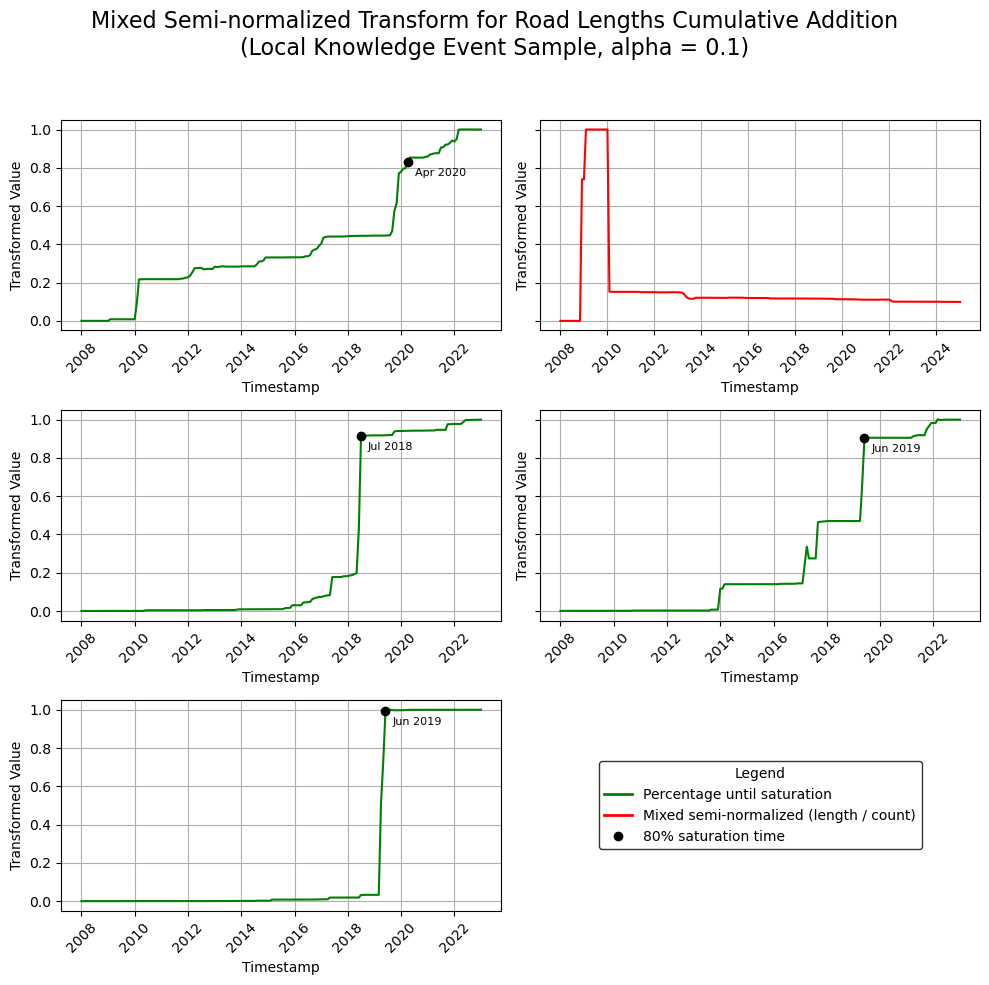

In [47]:
# Defining dataframes and subplot titles
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10), sharey=True)
axes = axes.flatten()

for i, (df, ax) in enumerate(zip(roads_test_samp, axes)):
    # Saturated values:
    if 'percentage_until_saturation' in df.columns:
        # Plotting
        df_plt = df.iloc[:-1]
        ax.plot(df_plt['timestamp'], df_plt['percentage_until_saturation'], linestyle='-', color='g', label='Percentage until saturation')

        # Adding saturation point
        saturation = df[df['percentage_until_saturation'] >= 0.8].iloc[0]
        ax.scatter(saturation['timestamp'], saturation['percentage_until_saturation'], color='black', zorder=5, label='80% saturation')
        ax.annotate(pd.to_datetime(saturation['timestamp']).strftime('%b %Y'), xy=(saturation['timestamp'], saturation['percentage_until_saturation']),
                    xytext=(5, -10), textcoords='offset points', fontsize=8, color='black')

    # Un-saturated values:      
    else: 
        ax.plot(df['timestamp'], df['normalized_cum_per'], linestyle='-', color='r', label='Mixed semi-normalized (length / count)')
    ax.set_ylabel('Transformed Value')
    ax.set_xlabel('Timestamp')
    ax.tick_params(axis='x', rotation=45)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(True)

# Setting legend
empty_ax = axes[-1]
empty_ax.axis('off')
legend_elements = [
    Line2D([0], [0], color='g', lw=2, label='Percentage until saturation'),
    Line2D([0], [0], color='r', lw=2, label='Mixed semi-normalized (length / count)'),
    Line2D([0], [0], marker='o', color='black', linestyle='', label='80% saturation time')
]
legend = empty_ax.legend(handles=legend_elements, loc='center', frameon=True, title='Legend')
legend.get_frame().set_edgecolor('black')

# Showing plots
fig.suptitle('Mixed Semi-normalized Transform for Road Lengths Cumulative Addition\n(Local Knowledge Event Sample, alpha = 0.1)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

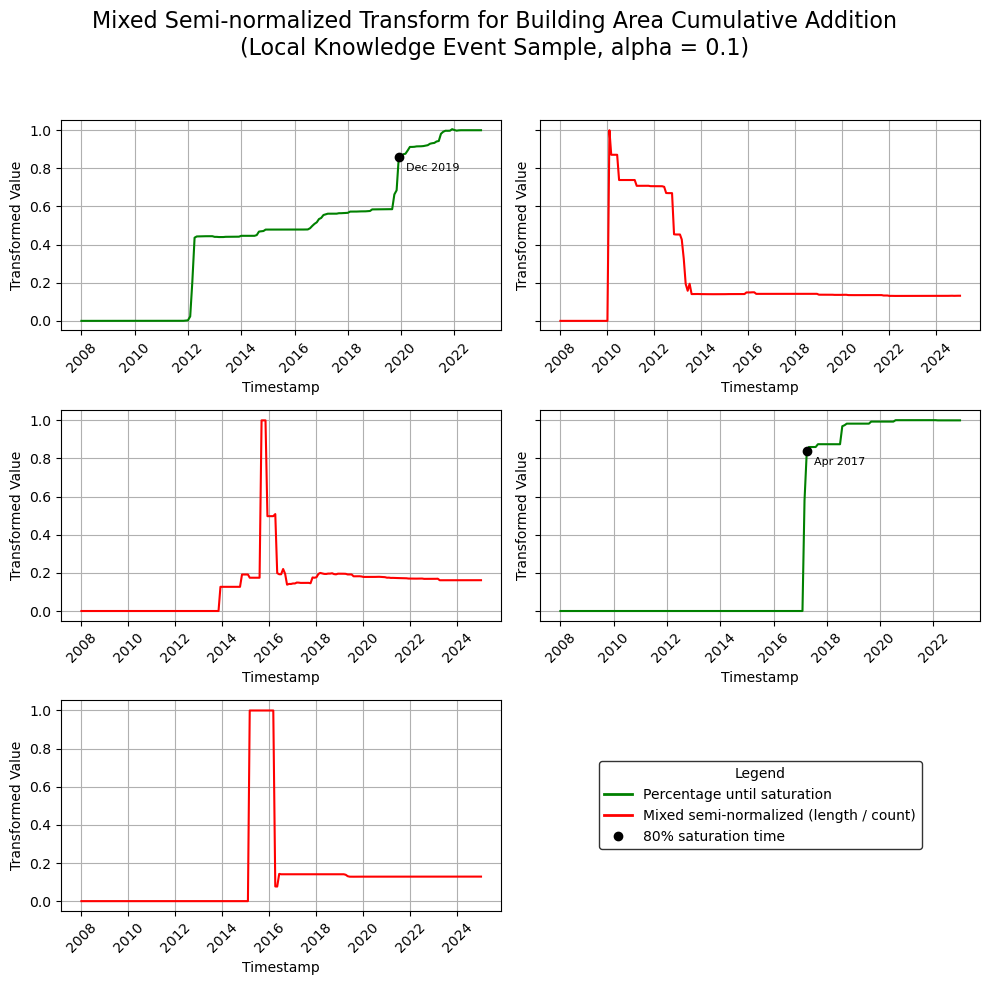

In [48]:
# Defining dataframes and subplot titles
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10), sharey=True)
axes = axes.flatten()

for i, (df, ax) in enumerate(zip(bldgs_test_samp, axes)):
    # Saturated values:
    if 'percentage_until_saturation' in df.columns:
        # Plotting
        df_plt = df.iloc[:-1]
        ax.plot(df_plt['timestamp'], df_plt['percentage_until_saturation'], linestyle='-', color='g', label='Percentage until saturation')

        # Adding saturation point
        saturation = df[df['percentage_until_saturation'] >= 0.8].iloc[0]
        ax.scatter(saturation['timestamp'], saturation['percentage_until_saturation'], color='black', zorder=5, label='80% saturation')
        ax.annotate(pd.to_datetime(saturation['timestamp']).strftime('%b %Y'), xy=(saturation['timestamp'], saturation['percentage_until_saturation']),
                    xytext=(5, -10), textcoords='offset points', fontsize=8, color='black')

    # Un-saturated values:      
    else: 
        ax.plot(df['timestamp'], df['normalized_cum_per'], linestyle='-', color='r', label='Mixed semi-normalized (length / count)')
    ax.set_ylabel('Transformed Value')
    ax.set_xlabel('Timestamp')
    ax.tick_params(axis='x', rotation=45)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(True)

# Setting legend
empty_ax = axes[-1]
empty_ax.axis('off')
legend_elements = [
    Line2D([0], [0], color='g', lw=2, label='Percentage until saturation'),
    Line2D([0], [0], color='r', lw=2, label='Mixed semi-normalized (length / count)'),
    Line2D([0], [0], marker='o', color='black', linestyle='', label='80% saturation time')
]
legend = empty_ax.legend(handles=legend_elements, loc='center', frameon=True, title='Legend')
legend.get_frame().set_edgecolor('black')

# Showing plots

fig.suptitle('Mixed Semi-normalized Transform for Building Area Cumulative Addition\n(Local Knowledge Event Sample, alpha = 0.1)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### Test entire sample

In [ ]:
# Use wrapper function to extract way counts for all rows
counts_rds = pd.concat(
    events_sample.apply(lambda row: wrap_api_query(row, query='count'), axis=1).tolist(),
    ignore_index=True
)

# Use wrapper function to extract way lengths for all rows
lengths = pd.concat(
    events_sample.apply(lambda row: wrap_api_query(row, query='length'), axis=1).tolist(),
    ignore_index=True
)

# Use wrapper function to extract building counts for all rows
counts_bld = pd.concat(
    events_sample.apply(lambda row: wrap_api_query(row, query='count', filter='type:way and building=*'), axis=1).tolist(),
    ignore_index=True
)

# Use wrapper function to extract building areas for all rows
areas = pd.concat(
    events_sample.apply(lambda row: wrap_api_query(row, query='area', filter='type:way and building=*'), axis=1).tolist(),
    ignore_index=True
)

In [49]:
counts_bld = pd.concat(
    events_sample.apply(lambda row: wrap_api_query(row, query='count', filter='type:way and building=*'), axis=1).tolist(),
    ignore_index=True
)

In [ ]:
# Road test for entire sample
roads_test = []

for idx, count_group in counts_rds.groupby('idx'):
    len_group = lengths[lengths['idx'] == idx].copy() # grouping length dataframe entries
    t1 = semi_norm_mix_transform(count_group, len_group)
    t1.loc[:, 'idx'] = idx  # preserve original index
    roads_test.append(t1)

roads_test = pd.concat(roads_test, ignore_index=True)

In [51]:
# Building test for entire sample
bldgs_test = []

for idx, count_group in counts_bld.groupby('idx'):
    area_group = areas[areas['idx'] == idx].copy() # grouping area dataframe entries
    t2 = semi_norm_mix_transform(count_group, area_group)
    t2.loc[:, 'idx'] = idx # preserve original index
    bldgs_test.append(t2)

bldgs_test = pd.concat(bldgs_test, ignore_index=True)

In [55]:
# Fixing deleted column values for roads
roads_test['event_type'] = roads_test.groupby('idx')['event_type'].transform(lambda x: x.fillna(x.mode().iloc[0]))
roads_test['event_percentage'] = roads_test.groupby('idx')['event_percentage'].transform(lambda x: x.fillna(x.mode().iloc[0]))

# Fixing deleted column values for buildings
bldgs_test['event_type'] = bldgs_test.groupby('idx')['event_type'].transform(lambda x: x.fillna(x.mode().iloc[0]))
bldgs_test['event_percentage'] = bldgs_test.groupby('idx')['event_percentage'].transform(lambda x: x.fillna(x.mode().iloc[0]))

In [56]:
# Filtering only saturation and current rows or last 2 rows for unsaturated indices
roads_test_threshold = roads_test[
    (roads_test['percentage_until_saturation'] >= 1) | (roads_test['percentage_until_saturation'].isna())
].groupby('idx').tail(2)

bldgs_test_threshold = bldgs_test[
    (bldgs_test['percentage_until_saturation'] >= 1) | (bldgs_test['percentage_until_saturation'].isna())
].groupby('idx').tail(2)

In [69]:
# Applying test results for each row in original sub-sample
results = events_sample[['event_type', 'event_percentage', 'bbox']].copy() # Clean DF

# Mapping road completeness values
road_completeness_map = roads_test_threshold.groupby('idx').tail(1).set_index('idx')['percentage_until_saturation'].notna().astype(int) # Reindexing and mapping boolean test check
results['road_completeness'] = results.index.map(road_completeness_map).fillna(0).astype(int) # Mapping each index to correct test result

# Mapping building completeness values
bldg_completeness_map = bldgs_test_threshold.groupby('idx').tail(1).set_index('idx')['percentage_until_saturation'].notna().astype(int) # Reindexing and mapping boolean test check
results['building_completeness'] = results.index.map(bldg_completeness_map).fillna(0).astype(int) # Mapping each index to correct test result

In [72]:
results.head()


,event_type,event_percentage,bbox,road_completeness,building_completeness
0,local_knowledge,63.997417,"-72.7734375,18.984375,-72.421875,19.16015625",1,1
1,local_knowledge,67.598822,"-72.421875,19.6875,-71.71875,20.0390625",1,1
2,local_knowledge,68.649403,"32.34375,-25.83984375,32.6953125,-25.6640625",1,1
3,local_knowledge,66.094857,"27.421875,-16.5234375,28.125,-16.171875",1,1
4,local_knowledge,66.532091,"34.453125,-19.6875,35.15625,-19.3359375",1,1


In [ ]:
# Save results to csv
results.to_csv(r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\1. Threshold exploration\event_sample_results_alpha=0_3.csv', index=False)

##### Measuring success

In [77]:
complete_road = sum(results['road_completeness'])
complete_bld = sum(results['building_completeness'])

In [81]:
print('Road Completeness:')
print(f'   n = {complete_road}\n   percentage = {round(complete_road / 446, 3)}')
print('\nBuilding Completeness:')
print(f'   n = {complete_bld}\n   percentage = {round(complete_bld / 446, 3)}')

Road Completeness:
   n = 398
   percentage = 0.892

Building Completeness:
   n = 5
   percentage = 0.011
